In [1]:
%load_ext autoreload
%autoreload 2

***
# 511 keV background estimation

**Objective**


This notebook follows the COSIpy line-background tutorial. It constructs a data-driven background estimate from measured-energy sidebands, generates several spatially filtered variants, and prepares them for validation against the simulated DC4 total background.


***
## Setup

### Imports

In [2]:
# Setting the root path for the imports
from pathlib import Path
import sys

working_dir=Path.cwd()
repo_root = (
    working_dir.parent 
    if working_dir.name =='notebooks' 
    else working_dir
    )
if str(repo_root) not in sys.path: sys.path.insert(0,str(repo_root))

In [3]:

import numpy as np
import cosipy as cp
import matplotlib.pyplot as plt


# # from cosipy.response import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

# # from scoords import SpacecraftFrame

from astropy.io import fits
import astropy.units as u
# # from astropy.coordinates import SkyCoord
# # from astromodels import Parameter, Powerlaw

import h5py
import healpy as hp


%matplotlib inline

### Paths to input products

In [4]:
# Input products: paths used in this analysis. See `workflow/src/path_to_files.py`.
from src import path_to_files as paths
from src.binning_config import write_custom_binning_yaml

In [5]:
# Validate input products
print(paths.simulated_background_path)
print(paths.data_dir_out)

/Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz
/Users/maura/Documents/COSI/data-challenge-4/workflow/data/outputs


## Data-driven background estimation

The  workflow used here has four stages:

1. Inspect the measured-energy spectrum around 511 keV.
2. Re-bin the weekly events with fine measured-energy bins.
3. Fit a spectral background model outside the source-dominated region.
4. Use energy sidebands to generate spatial background templates in `Phi` and `PsiChi`.

The resulting templates will later be compared with the simulated DC4 total background before one is selected for imaging.

### Inspect the measured-energy spectrum

In [6]:
# Inspect the FITS files with fits.open.
with fits.open(paths.weekly_paths[1]) as hdul:
        print(hdul.info())
        print(hdul[1].columns.names)
        

Filename: /Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/dc4_mock_dataset_week_1_unbinned_data_filtered_with_SAAcut.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     45   13829698R x 11C   [D, D, 2D, 2D, 2D, D, D, D, D, D, D]   
None
['Energies', 'TimeTags', 'Xpointings (glon,glat)', 'Ypointings (glon,glat)', 'Zpointings (glon,glat)', 'Phi', 'Chi local', 'Psi local', 'Distance', 'Chi galactic', 'Psi galactic']


In [7]:
# Select events between 450 and 600 keV from every week.

# Initialize the energy spectrum per week
selected_energies_by_week = []

# Extract the measured energies around the 511 keV feature.
# This will be done for each week 
for week, input_path in paths.weekly_paths.items():
    with fits.open(input_path) as hdul:
        energies = hdul[1].data["Energies"]

        # Applying mask for energy of interest (450, 600)
        energy_mask = (
            (energies >= 450) 
            & (energies <= 600)
        )

        selected_energies = np.asarray (
            energies[energy_mask]
        )

    selected_energies_by_week.append(selected_energies)
    print(week, selected_energies.size)


1 1198205
2 1207013
3 1215053
4 1219214
5 1224807
6 1225702
7 1230531
8 1230480
9 1219659
10 1202723
11 1204123
12 1205023
13 1203211
14 232490


In [8]:
# Define 1 keV bin edges to convert the selected events into an energy spectrum.
# These edges define the histogram bins.
energy_bin_edges = np.arange(450, 601, 1, dtype=float)

In [9]:
# Initialize the combined energy spectrum

energy_counts_all = np.zeros(
    len(energy_bin_edges) - 1,
    dtype=int,
)

# Build and combine the energy spectrum from all weeks 
for week_energies in selected_energies_by_week:
    week_counts, _ = np.histogram(
        week_energies,
        bins=energy_bin_edges
    )
    energy_counts_all += week_counts

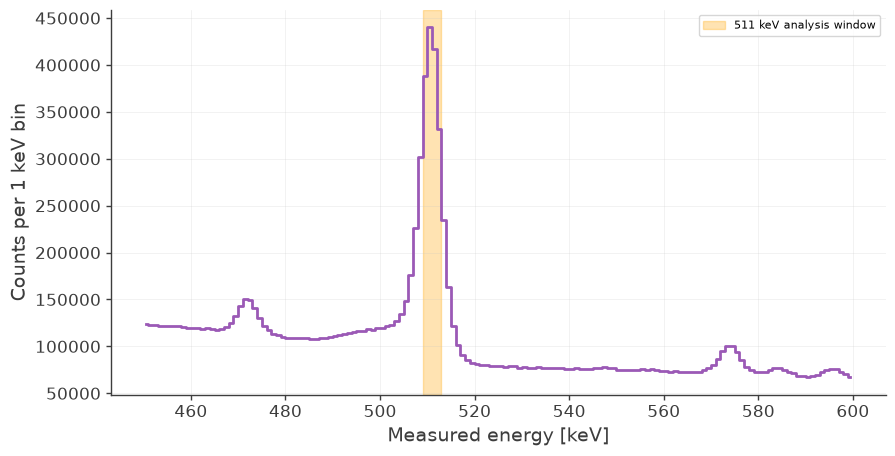

In [10]:
# Calculate the center of each energy bin
energy_bin_centers = 0.5 * (
    energy_bin_edges[:-1] + energy_bin_edges[1:]
)

    # Plot the combined energy spectrum
plt.figure(figsize=(10, 5))
plt.step(
    energy_bin_centers,
    energy_counts_all,
    where="mid",
)

# Highlight the 511 keV analysis window
plt.axvspan(
    509,
    513,
    color="orange",
    alpha=0.3,
    label="511 keV analysis window",
)

plt.xlabel("Measured energy [keV]")
plt.ylabel("Counts per 1 keV bin")
plt.legend()
plt.grid(alpha=0.3)


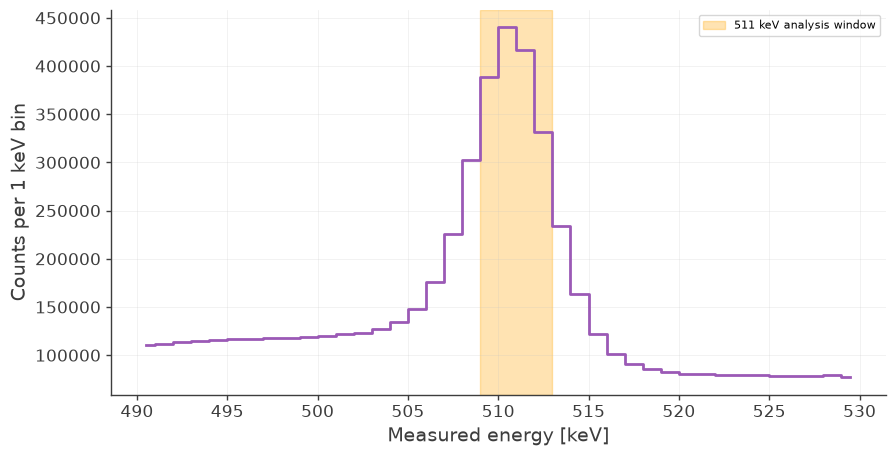

In [11]:
# Select the region around the 511 keV feature
zoom_mask = (
    (energy_bin_centers >= 490)
    & (energy_bin_centers <= 530)
)

# Plot a closer view of the 511 keV feature
plt.figure(figsize=(10, 5))
plt.step(
    energy_bin_centers[zoom_mask],
    energy_counts_all[zoom_mask],
    where="mid",
)

# Highlight the final 511 keV analysis window
plt.axvspan(
    509,
    513,
    color="orange",
    alpha=0.3,
    label="511 keV analysis window",
)

plt.xlabel("Measured energy [keV]")
plt.ylabel("Counts per 1 keV bin")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The broad 450–600 keV interval is used only to inspect the local spectrum and identify nearby structures. The auxiliary product below is restricted to 480–540 keV with 1 keV bins, providing the energy resolution needed by `LineBackgroundEstimation`.


### Fine-energy binning for background estimation

In [12]:
# define the fine energy bins for the background-estimation product 
background_energy_bin_edges = np.arange(
    480,
    541,
    1,
    dtype=float,
)
# checking the auxiliarity energy binning
print('Number of bins:', len(background_energy_bin_edges) - 1)
print('Energy range', background_energy_bin_edges[[0,-1]])

Number of bins: 60
Energy range [480. 540.]


In [13]:
background_yaml_path = paths.config_511_background_path

# Create the background-binning YAML configuration if it does not exist.
# This configuration is used below to bin the weekly data.

if not background_yaml_path.exists():
    write_custom_binning_yaml(
        base_yaml_path=paths.config_511_path,
        output_yaml_path=background_yaml_path,
        energy_bins= background_energy_bin_edges
    )
    print("Background YAML file for binning was created in:",  background_yaml_path)
else:
    print("Background YAML file for binning already exists:", background_yaml_path)

Background YAML file for binning already exists: /Users/maura/Documents/COSI/data-challenge-4/workflow/config/dataio_511_background.yaml


In [14]:
# Create and load the auxiliary background products for all weeks.
background_analysis = {}


# Bin the data files for every week.
for week, input_path in paths.weekly_paths.items():
    # Path and filename prefix for the desired output.
    output_prefix = (
        paths.data_dir_out
        / f"dc4_week_{week}_511_background_binned"
    )
    output_path = output_prefix.with_suffix(".hdf5")


    # Create the weekly BinnedData object.
    background_analysis[week] = cp.BinnedData(
        background_yaml_path
    )

    # Bin the weekly events only if the output is missing.
    if not output_path.exists():
        background_analysis[week].get_binned_data(
            unbinned_data=str(input_path),
            output_name=str(output_prefix),
        )

    # Always load the existing or newly created histogram.
    background_analysis[week].load_binned_data_from_hdf5(
        binned_data=str(output_path)
    )

    # Initialize the binning metadata from the loaded histogram.
    background_analysis[week].get_binning_info()


In [15]:
# The background model requires a statistically stable description of the event distribution in detector data space.
# We therefore combine all times and weeks while preserving the measured-energy and Compton-event coordinates (`Em`, `Phi`, and `PsiChi`).

# Sum over the time axis of week 1 while preserving the
# measured-energy and Compton-data-space dimensions.
background_hist_all = (
    background_analysis[1] # just week 1
    .binned_data
    .project("Em", "Phi", "PsiChi")
)

# Combine the remaining weeks into one histogram containing
# the complete dataset used for background estimation.
for week in range(2, 15):
    week_hist = (
        background_analysis[week] # all the weeks from 2 to 14
        .binned_data
        .project("Em", "Phi", "PsiChi")
    )

    background_hist_all = background_hist_all + week_hist

In [16]:
# Validate the combined histogram
print("Shape:", background_hist_all.shape)
print("Axes:", background_hist_all.axes.labels)
print("Sparse:", background_hist_all.is_sparse)

Shape: (60, 60, 3072)
Axes: ['Em' 'Phi' 'PsiChi']
Sparse: True


`background_hist_all` contains the 14-week observation projected onto `Em`, `Phi`, and `PsiChi`. It still contains both source and background events; the name indicates its role as input to the background estimator, not that it is already a pure-background histogram.

### Line-background estimator and spectral fit

The COSIpy tutorial models a smooth power-law continuum plus Gaussian instrumental-line components. Its Al-26 example uses several Gaussians. For the local 480–540 keV interval, the same tutorial structure is tested with one Gaussian component around the dominant line-like feature.

The final 509–513 keV science window is excluded from the fit. The surrounding continuum and unmasked line wings constrain the spectral model.

In [17]:
# Initialize the 511 keV line-background estimator.
line_background_estimator = cp.LineBackgroundEstimation(background_hist_all)

(<Axes: xlabel='Em [keV]'>, <Quantity 512. keV>)

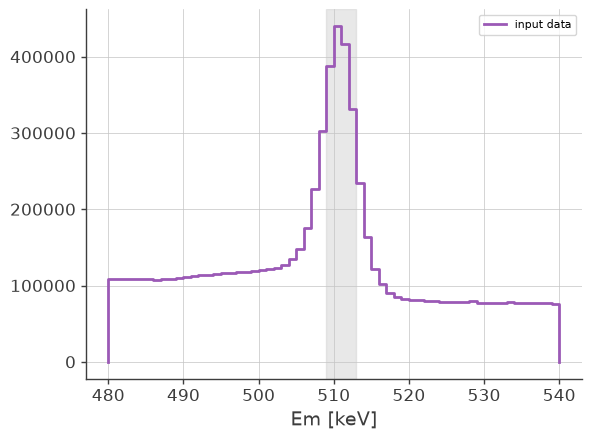

In [18]:
# Exclude exactly the four 1 keV bins spanning 509--513 keV.
# Small offsets prevent COSIpy from also masking the adjacent edge-touching bins.
fit_exclusion_range = (
    np.array([509.0 + 1e-6, 513.0 - 1e-6]) * u.keV
)

line_background_estimator.set_mask(
    fit_exclusion_range
)

line_background_estimator.plot_energy_spectrum()

Define a background spectrum model for fitting the data

In [19]:
def powerlaw(x, a, b, pivot):
    return a * (x/pivot)**b

def gaussian(x, a, mu, sigma):
    return a / (sigma) / np.sqrt(2 * np.pi) * np.exp( -(x-mu)**2 / (2*sigma**2))


# Following the tutorial, the final 511 keV science window is masked.
# The power law describes the continuum, while the Gaussian describes the
# broader instrumental line using the unmasked line wings.

def bkg_model(x, a, b, a1, mu1, sigma ): # , a1, mu1, sigma, a2, mu2, a3, mu3, a4, mu4, a5, mu5, a6, mu6):
    pivot = 511.0
    return powerlaw(x,a,b, pivot)  +  gaussian(x , a1, mu1, sigma) # + \
            # gaussian(x , a2, mu2, sigma) + \
            # gaussian(x , a3, mu3, sigma) + \
            # gaussian(x , a4, mu4, sigma) + \
            # gaussian(x , a5, mu5, sigma) + \
            # gaussian(x , a6, mu6, sigma)

(<Axes: xlabel='Em [keV]'>, <Quantity 512. keV>)

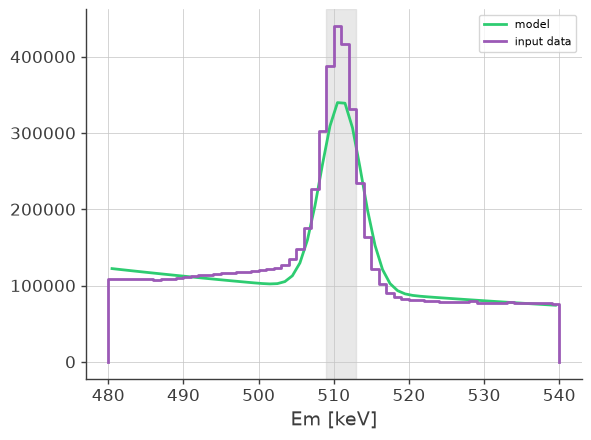

In [20]:
# Initial guesses for the continuum and instrumental-line components.
initial_line_model_parameters = [
    9.369e4,   # Continuum normalization near 511 keV
    -4.313,    # Continuum power-law index
    1.691e6,   # Integrated counts in the Gaussian component
    511,   # Gaussian center in keV
    2.684,     # Gaussian sigma in keV
]

line_background_estimator.set_bkg_energy_spectrum_model(bkg_model,initial_line_model_parameters,)
line_background_estimator.plot_energy_spectrum()

In [21]:
# Constrain only parameters that have physical restrictions.
line_parameter_limits = {
    0: (0.0, None),     # Continuum normalization must be positive
    2: (0.0, None),     # Gaussian area must be positive
    3: (509.0, 513.0),  # Line center must remain around 511 keV
    4: (0.01, None),     # Gaussian width must be positive and non-zero
}

# Retry from the parameters saved by the previous attempt, if needed.
max_fit_attempts = 10

for fit_attempt in range(1, max_fit_attempts + 1):
    line_model_fit = line_background_estimator.fit_energy_spectrum(
        param_limits=line_parameter_limits
    )

    if line_model_fit.valid:
        break
else:
    raise RuntimeError(
        f"The spectral fit did not converge after {max_fit_attempts} attempts."
    )

print(f"Fit converged after {fit_attempt} attempt(s).")
line_model_fit

Fit converged after 2 attempt(s).


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -6.573e+07                 │              Nfcn = 216              │
│ EDM = 4.3e-06 (Goal: 0.0001)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0   │  93.69e3  │  0.05e3   │            │            │    0    │         │       │
│ 1 │ x1   │  -4.314   │   0.012   │            │            │         │         │       │
│ 2 │ x2   │ 1.6913e6  │ 0.0032e6  │            │            │    0    │         │       │
│ 3 │ x3   │  510.346  │   0.004   │            │            │   509   │   513   │       │
│ 4 │ x4   │   2.683   │   0.005   │            │            │  0.01   │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬────────────────────────────────────────────────────────┐
│    │         x0         x1         x2         x3         x4 │
├────┼────────────────────────────────────────────────────────┤
│ x0 │   2.25e+03  136.60e-3    -19.2e3  18.846e-3 -74.791e-3 │
│ x1 │  136.60e-3   0.000155   -2.19324  -0.003e-3  -0.001e-3 │
│ x2 │    -19.2e3   -2.19324   1.03e+07   4.785751  -7.013319 │
│ x3 │  18.846e-3  -0.003e-3   4.785751   1.65e-05  -0.009e-3 │
│ x4 │ -74.791e-3  -0.001e-3  -7.013319  -0.009e-3   2.64e-05 │
└────┴────────────────────────────────────────────────────────┘

In [22]:
# Store and display the final fitted parameters.
fitted_line_model_parameters = list(line_model_fit.values)

print(fitted_line_model_parameters)

[93687.46357348144, -4.313568503100249, 1691319.5874997429, 510.34643013489614, 2.6833784836771937]


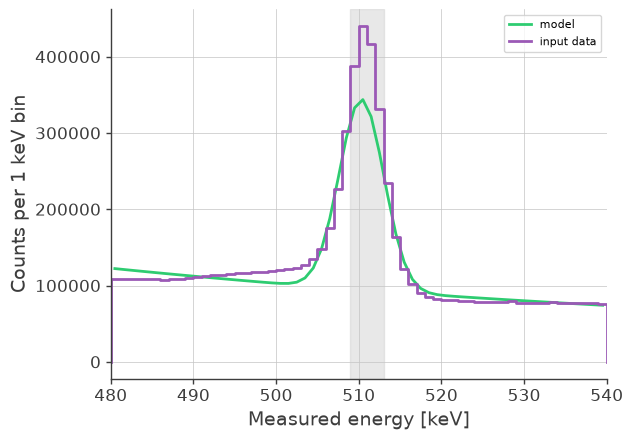

In [23]:
# Plot the fitted continuum-plus-line model over the observed spectrum.
ax, _ = line_background_estimator.plot_energy_spectrum()

ax.set_xlim(480, 540)
ax.set_xlabel("Measured energy [keV]")
ax.set_ylabel("Counts per 1 keV bin")

plt.show()

### Source window and background sidebands

In [24]:
# Final science window for the 511 keV analysis.

source_energy_range = (
    np.array([509.0, 513.0]) * u.keV
)

# Combined baseline: use every sideband bin outside the source window.
background_region_low = (
    np.array([480.0, 509.0]) * u.keV
)
background_region_high = (
    np.array([513.0, 540.0]) * u.keV
)

# Far sidebands used to estimate the smooth continuum background.
continuum_region_low = (
    np.array([480.0, 503.0]) * u.keV
)
continuum_region_high = (
    np.array([520.0, 540.0]) * u.keV
)

# Near sidebands used to trace the instrumental-line wings.
line_wing_region_low = (
    np.array([503.0, 509.0]) * u.keV
)
line_wing_region_high = (
    np.array([513.0, 520.0]) * u.keV
)

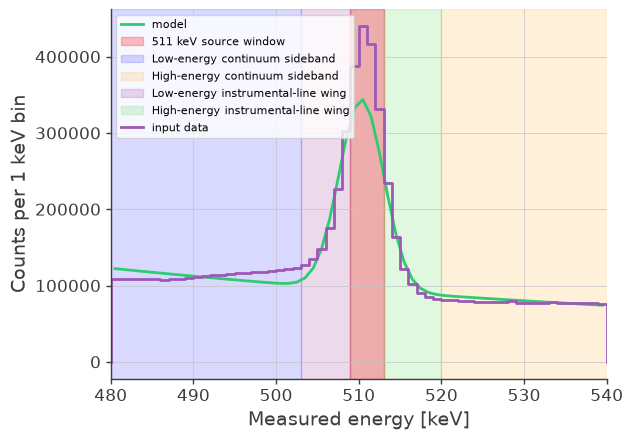

In [25]:
# Visualize the source window and the sidebands used for background estimation.
ax, _ = line_background_estimator.plot_energy_spectrum()

ax.axvspan(
    source_energy_range[0].value,
    source_energy_range[1].value,
    color="red",
    alpha=0.25,
    label="511 keV source window",
)

ax.axvspan(
    continuum_region_low[0].value,
    continuum_region_low[1].value,
    color="blue",
    alpha=0.15,
    label="Low-energy continuum sideband",
)

ax.axvspan(
    continuum_region_high[0].value,
    continuum_region_high[1].value,
    color="orange",
    alpha=0.15,
    label="High-energy continuum sideband",
)



ax.axvspan(
    line_wing_region_low[0].value,
    line_wing_region_low[1].value,
    color="purple",
    alpha=0.15,
    label="Low-energy instrumental-line wing",
)

ax.axvspan(
    line_wing_region_high[0].value,
    line_wing_region_high[1].value,
    color="limegreen",
    alpha=0.15,
    label="High-energy instrumental-line wing",
)
ax.set_xlim(480, 540)
ax.set_xlabel("Measured energy [keV]")
ax.set_ylabel("Counts per 1 keV bin")
ax.legend()

plt.show()

### Background variants

Five spatial-processing variants are generated for the combined baseline and separately for the far-continuum and instrumental-line-wing sidebands:

- `raw`: the unfiltered sideband template.
- `smoothing`: Gaussian angular smoothing with a 20 degree FWHM.
- `l_cut`: harmonic filtering that retains multipoles through `l = 4`.
- `rebin+smoothing`: temporary grouping of 10 `Phi` bins before smoothing.
- `rebin+l_cut`: temporary grouping of 10 `Phi` bins before harmonic filtering.

These are not different spectral fits. Within each sideband family, they share the fitted spectral model and differ only in how the spatial template is filtered. The combined baseline and the two separated raw estimates are compared directly with the simulated background below.


In [26]:
# Define the spatial-processing settings for each background model.
background_model_settings = {
    "raw": {},

    "smoothing": {
        "smoothing_fwhm": 20 * u.deg,
    },

    "l_cut": {
        "l_cut": 4,
    },

    "rebin_smoothing": {
        "rebin_phi": 10,
        "smoothing_fwhm": 20 * u.deg,
    },
    
    "rebin_l_cut": {
        "rebin_phi": 10,
        "l_cut": 4,
    },
}


In [27]:


# Generate all candidate background models and keep them in memory.
combined_models_511 = {}
continuum_models_511 = {}
line_wing_models_511 = {}


for name, settings in background_model_settings.items():
    combined_models_511[name] = (
        line_background_estimator.generate_bkg_model_histogram(
            source_energy_range=source_energy_range,
            bkg_estimation_energy_ranges=[
                background_region_low,
                background_region_high,
            ],
            **settings,
        )
    )
    continuum_models_511[name] = (
        line_background_estimator.generate_bkg_model_histogram(
            source_energy_range=source_energy_range,
            bkg_estimation_energy_ranges=[
                continuum_region_low,
                continuum_region_high,
            ],
            **settings,
        )
    )
    line_wing_models_511[name] = (
        line_background_estimator.generate_bkg_model_histogram(
            source_energy_range=source_energy_range,
            bkg_estimation_energy_ranges=[
                line_wing_region_low,
                line_wing_region_high,
            ],
            **settings,
            )
        )

# Keep all three raw sideband estimates together for direct validation.
diagnostic_background_models = {
    "combined_baseline": combined_models_511["raw"],
    "far_continuum": continuum_models_511["raw"],
    "line_wings": line_wing_models_511["raw"],
}

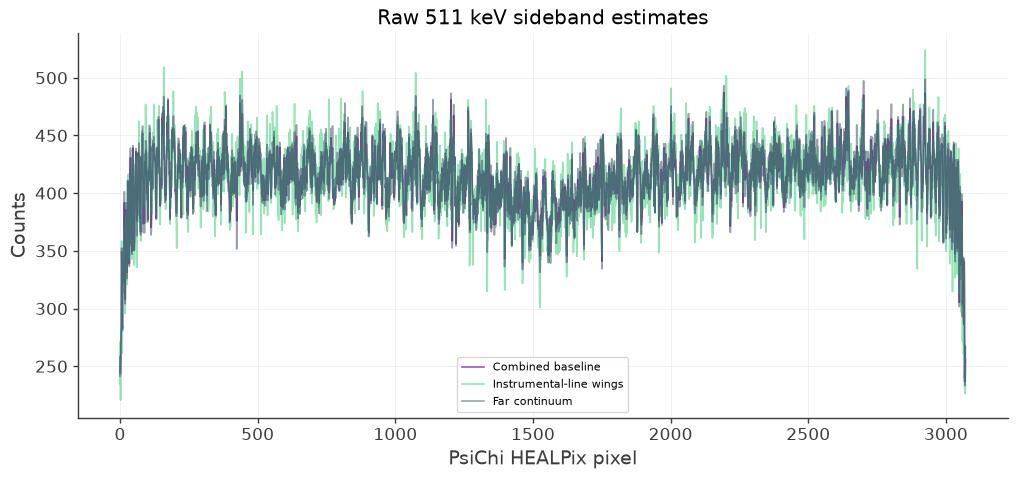

In [28]:
# Compare all three raw sideband estimates in one PsiChi projection.
fig, ax = plt.subplots(figsize=(12, 5))


psichi_projection_combined = (
            combined_models_511["raw"]
            .project("PsiChi")
            .to_dense(copy=False)
            )
psichi_projection_con = (
            continuum_models_511["raw"]
            .project("PsiChi")
            .to_dense(copy=False)
            )
psichi_projection_lin = (
            line_wing_models_511["raw"]
            .project("PsiChi")
            .to_dense(copy=False)
            )

values0 = np.asarray(psichi_projection_combined.contents)
values1 = np.asarray(psichi_projection_con.contents)
values2 = np.asarray(psichi_projection_lin.contents)
pixels0 = np.arange(values0.size)
pixels1 = np.arange(values1.size)
pixels2 = np.arange(values2.size)


ax.plot(
        pixels0,
        values0,
        label="Combined baseline",
        linewidth=1.2,
    )
ax.plot(
        pixels2,
        values2,
        label="Instrumental-line wings",
        linewidth=1.2,
        alpha=0.5,
    )
ax.plot(
        pixels1,
        values1,
        label="Far continuum",
        linewidth=1.2,
        alpha=0.5,
    )



ax.set_xlabel("PsiChi HEALPix pixel")
ax.set_ylabel("Counts")
ax.set_title("Raw 511 keV sideband estimates")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

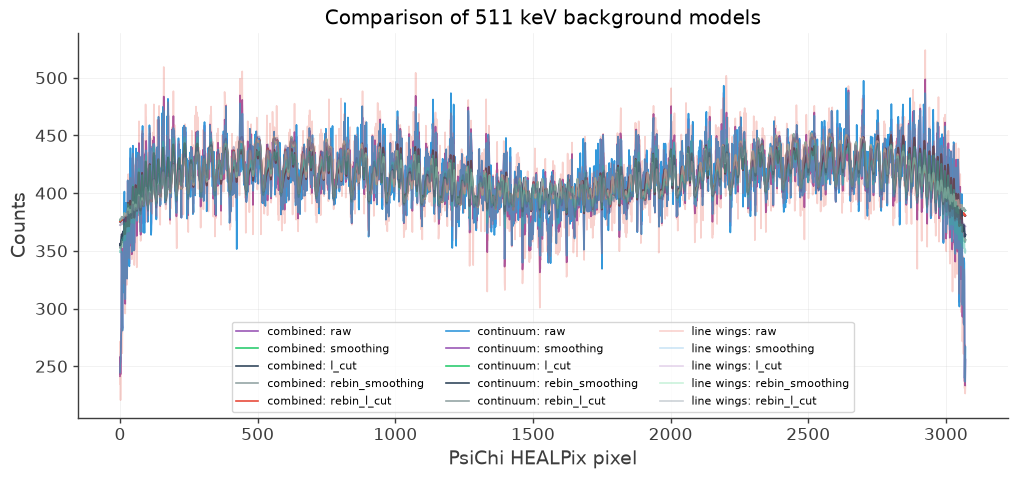

In [29]:
# Compare all background models using their PsiChi projections.

fig, ax = plt.subplots(figsize=(12, 5))

for name, model in combined_models_511.items():
    psichi_projection = (
        model
        .project("PsiChi")
        .to_dense(copy=False)
    )

    values = np.asarray(psichi_projection.contents)
    pixels = np.arange(values.size)

    ax.plot(
        pixels,
        values,
        label=f"combined: {name}",
        linewidth=1.2,
    )

for name, model in continuum_models_511.items():
    psichi_projection = (
        model
        .project("PsiChi")
        .to_dense(copy=False)
    )

    values = np.asarray(psichi_projection.contents)
    pixels = np.arange(values.size)

    ax.plot(
        pixels,
        values,
        label=f"continuum: {name}",
        linewidth=1.2,
    )

for name, model in line_wing_models_511.items():
    psichi_projection = (
        model
        .project("PsiChi")
        .to_dense(copy=False)
    )

    values = np.asarray(psichi_projection.contents)
    pixels = np.arange(values.size)

    ax.plot(
        pixels,
        values,
        label=f"line wings: {name}",
        linewidth=1.2,
        alpha=0.25,
    )

ax.set_xlabel("PsiChi HEALPix pixel")
ax.set_ylabel("Counts")
ax.set_title("Comparison of 511 keV background models")
ax.legend(ncol=3)
ax.grid(alpha=0.3)

plt.show()

## Validation with simulated background

1. Bin and load the provided simulated total background in the 509–513 keV window.
2. Compare its normalization with the combined baseline and the two separated raw estimates.
3. Compare the `Phi` distributions and residuals.
4. Compare the `PsiChi` distributions and residuals.

No model should be selected for the imaging analysis until these comparisons are complete.

### Download and bin the simulated data if not done yet

In [30]:
# Download the simulated DC4 total background used for validation.
simulated_background_remote_path = paths.simulated_background_remote_path
simulated_background_path = paths.simulated_background_path


if not simulated_background_path.exists():
    fetch_wasabi_file(
        simulated_background_remote_path,
        output=simulated_background_path,
    )
else:
    print(
        "Background file already exists:",
        simulated_background_path,
    )

Background file already exists: /Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz


In [31]:
# Create the BinnedData object using the final 509--513 keV binning.
simulated_background_analysis = cp.BinnedData(
    paths.config_511_path
)

# Bin the simulated background only if the output is missing.
if not paths.simulated_background_511_binned_path.exists():
    simulated_background_analysis.get_binned_data(
        unbinned_data=str(paths.simulated_background_path),
        output_name=str(
            paths.simulated_background_511_binned_path.with_suffix("")
        ),
    )

# Load the existing or newly generated histogram.
simulated_background_analysis.load_binned_data_from_hdf5(
    binned_data=str(
        paths.simulated_background_511_binned_path
    )
)
simulated_background_analysis.get_binning_info()

# Sum over time while preserving Em, Phi, and PsiChi.
simulated_background_511 = (
    simulated_background_analysis
    .binned_data
    .project("Em", "Phi", "PsiChi")
)

# Verify compatibility with the estimated background models.

print("Shape:", simulated_background_511.shape)
print("Axes:", simulated_background_511.axes.labels)
print(
    "Energy edges:",
    simulated_background_511.axes["Em"].edges,
)

Shape: (1, 60, 3072)
Axes: ['Em' 'Phi' 'PsiChi']
Energy edges: [509. 513.] keV


### Visualization and validation against the simulation

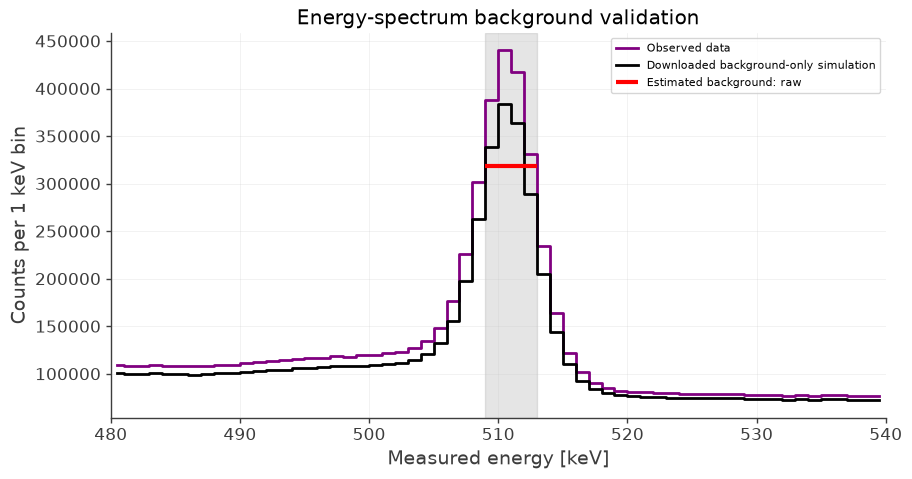

In [39]:
# Validate the observed spectrum and the raw background estimate
# against the downloaded background-only simulation.

observed_energy_spectrum = (
    background_hist_all
    .project("Em")
    .to_dense(copy=False)
)

with fits.open(
    simulated_background_path,
    memmap=True,
) as hdul:
    simulated_background_energy_counts, _ = np.histogram(
        hdul[1].data["Energies"],
        bins=background_energy_bin_edges,
    )

energy_centers = 0.5 * (
    background_energy_bin_edges[:-1]
    + background_energy_bin_edges[1:]
)

# The raw model contains one integrated 509--513 keV energy bin.
raw_background_counts = float(
    np.sum(
        combined_models_511["raw"]
        .to_dense(copy=False)
        .contents
    )
)

source_width = (
    source_energy_range[1] - source_energy_range[0]
).to_value(u.keV)

raw_background_counts_per_keV = (
    raw_background_counts / source_width
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.step(
    energy_centers,
    observed_energy_spectrum.contents,
    where="mid",
    color="purple",
    label="Observed data",
)

ax.step(
    energy_centers,
    simulated_background_energy_counts,
    where="mid",
    color="black",
    label="Downloaded background-only simulation",
)

ax.hlines(
    raw_background_counts_per_keV,
    source_energy_range[0].value,
    source_energy_range[1].value,
    color="red",
    linewidth=3,
    label="Estimated background: raw",
)

ax.axvspan(
    source_energy_range[0].value,
    source_energy_range[1].value,
    color="grey",
    alpha=0.2,
)

ax.set_xlim(480, 540)
ax.set_xlabel("Measured energy [keV]")
ax.set_ylabel("Counts per 1 keV bin")
ax.set_title("Energy-spectrum background validation")
ax.legend()
ax.grid(alpha=0.3)

plt.show()


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide



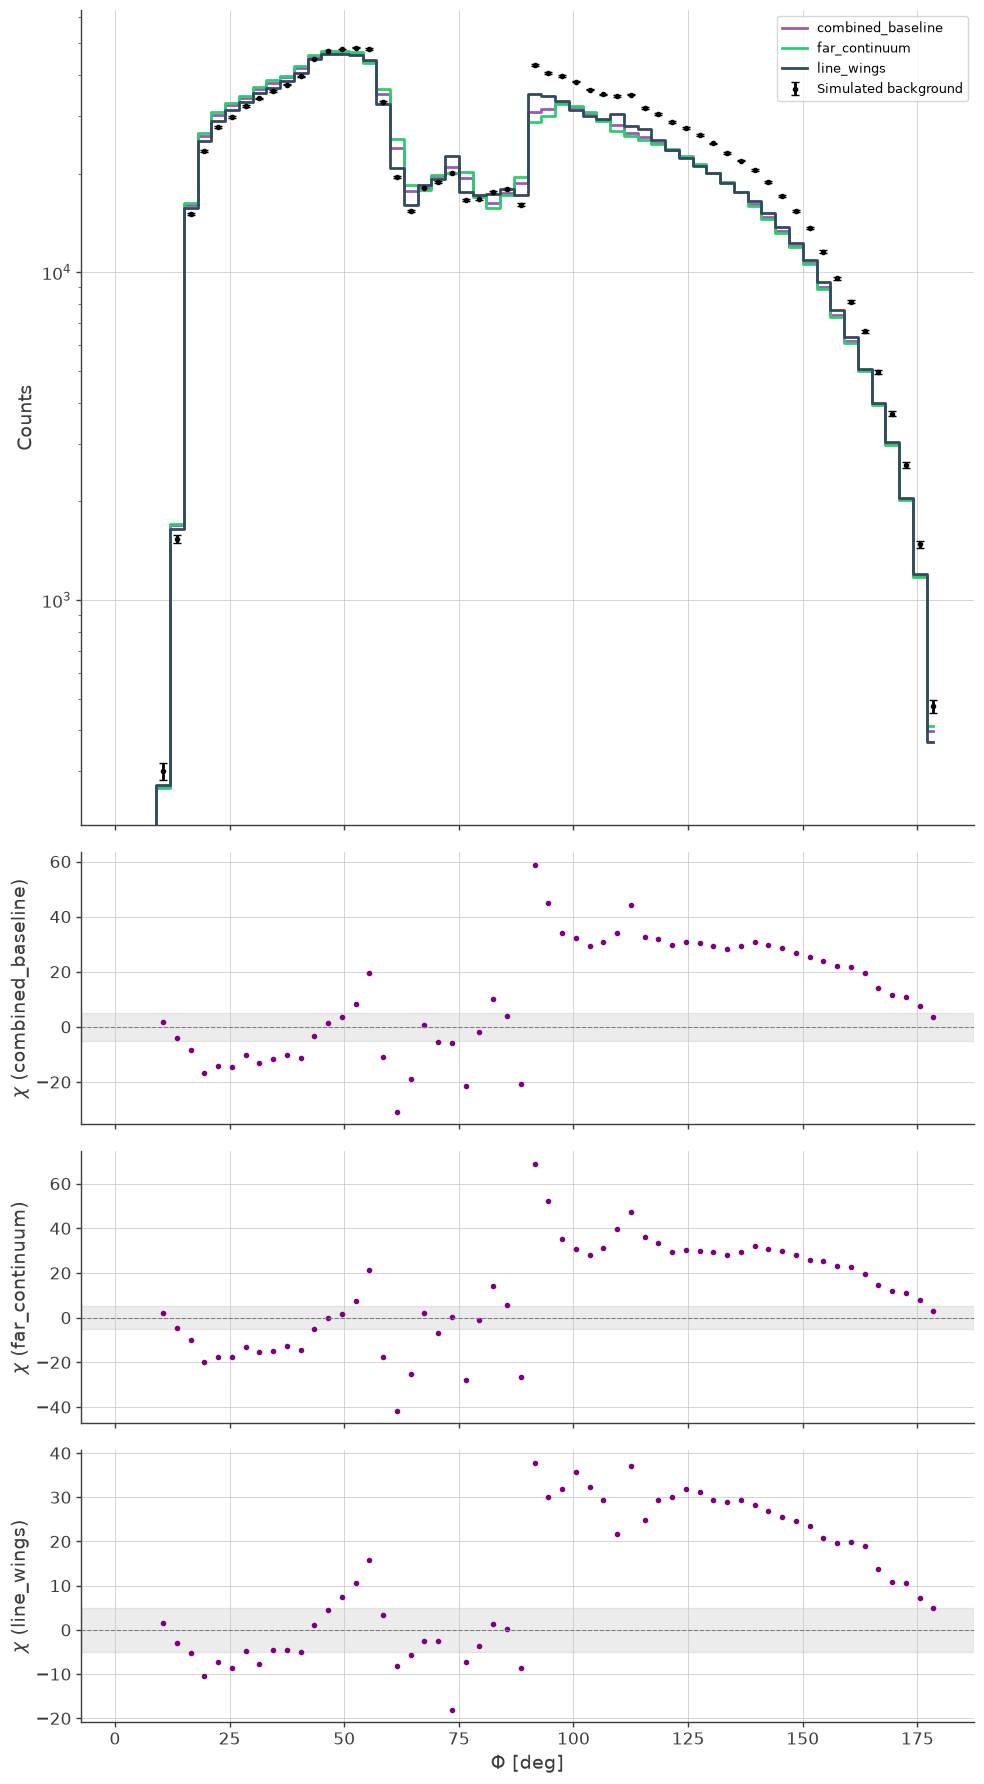

In [32]:
# Project the simulated background onto Phi.
phi_simulated = (
    simulated_background_511
    .project("Phi")
    .to_dense(copy=False)
)

phi_centers = (
    phi_simulated.axes["Phi"].centers
)

fig, axes = plt.subplots(
    len(diagnostic_background_models) + 1,
    1,
    figsize=(10, 18),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3]
        + [1] * len(diagnostic_background_models)
    },
)

# Plot the simulated background and every estimated model.
axes[0].errorbar(
    phi_centers,
    phi_simulated.contents,
    yerr=np.sqrt(phi_simulated.contents),
    fmt=".",
    color="black",
    label="Simulated background",
    capsize=3,
)

for name, model in diagnostic_background_models.items():
    phi_model = (
        model
        .project("Phi")
        .to_dense(copy=False)
    )

    axes[0].step(
        phi_centers,
        phi_model.contents,
        where="mid",
        label=name,
    )

axes[0].set_ylabel("Counts")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)
axes[0].grid()

# Plot standardized residuals for each model.
for ax, (name, model) in zip(
    axes[1:],
    diagnostic_background_models.items(),
):
    phi_model = (
        model
        .project("Phi")
        .to_dense(copy=False)
    )

    residual = (phi_simulated.contents- phi_model.contents) / np.sqrt(phi_simulated.contents)

    ax.plot(
        phi_centers,
        residual,
        ".",
        color="purple",
    )
    ax.axhline(
        0,
        color="grey",
        linestyle="--",
        linewidth=0.8,
    )
    ax.axhspan(
        -5,
        5,
        color="grey",
        alpha=0.15,
    )
    ax.set_ylabel(fr"$\chi$ ({name})")
   
    ax.grid()

axes[-1].set_xlabel(r"$\Phi$ [deg]")

plt.tight_layout()
plt.show()

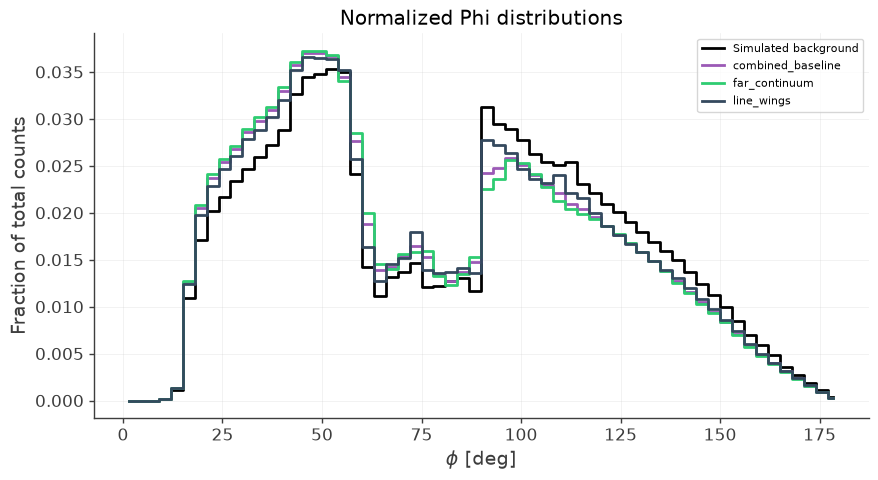

In [33]:
# Normalize the simulated Phi distribution to unit area.
phi_simulated_values = np.asarray(
    phi_simulated.contents,
    dtype=float,
)
phi_simulated_normalized = (
    phi_simulated_values
    / phi_simulated_values.sum()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.step(
    phi_centers,
    phi_simulated_normalized,
    where="mid",
    color="black",
    label="Simulated background",
)

# Normalize and compare every estimated model.
for name, model in diagnostic_background_models.items():
    phi_model = (
        model
        .project("Phi")
        .to_dense(copy=False)
    )

    model_values = np.asarray(
        phi_model.contents,
        dtype=float,
    )
    model_normalized = model_values / model_values.sum()

    ax.step(
        phi_centers,
        model_normalized,
        where="mid",
        label=name,
    )

ax.set_xlabel(r"$\phi$ [deg]")
ax.set_ylabel("Fraction of total counts")
ax.set_title("Normalized Phi distributions")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

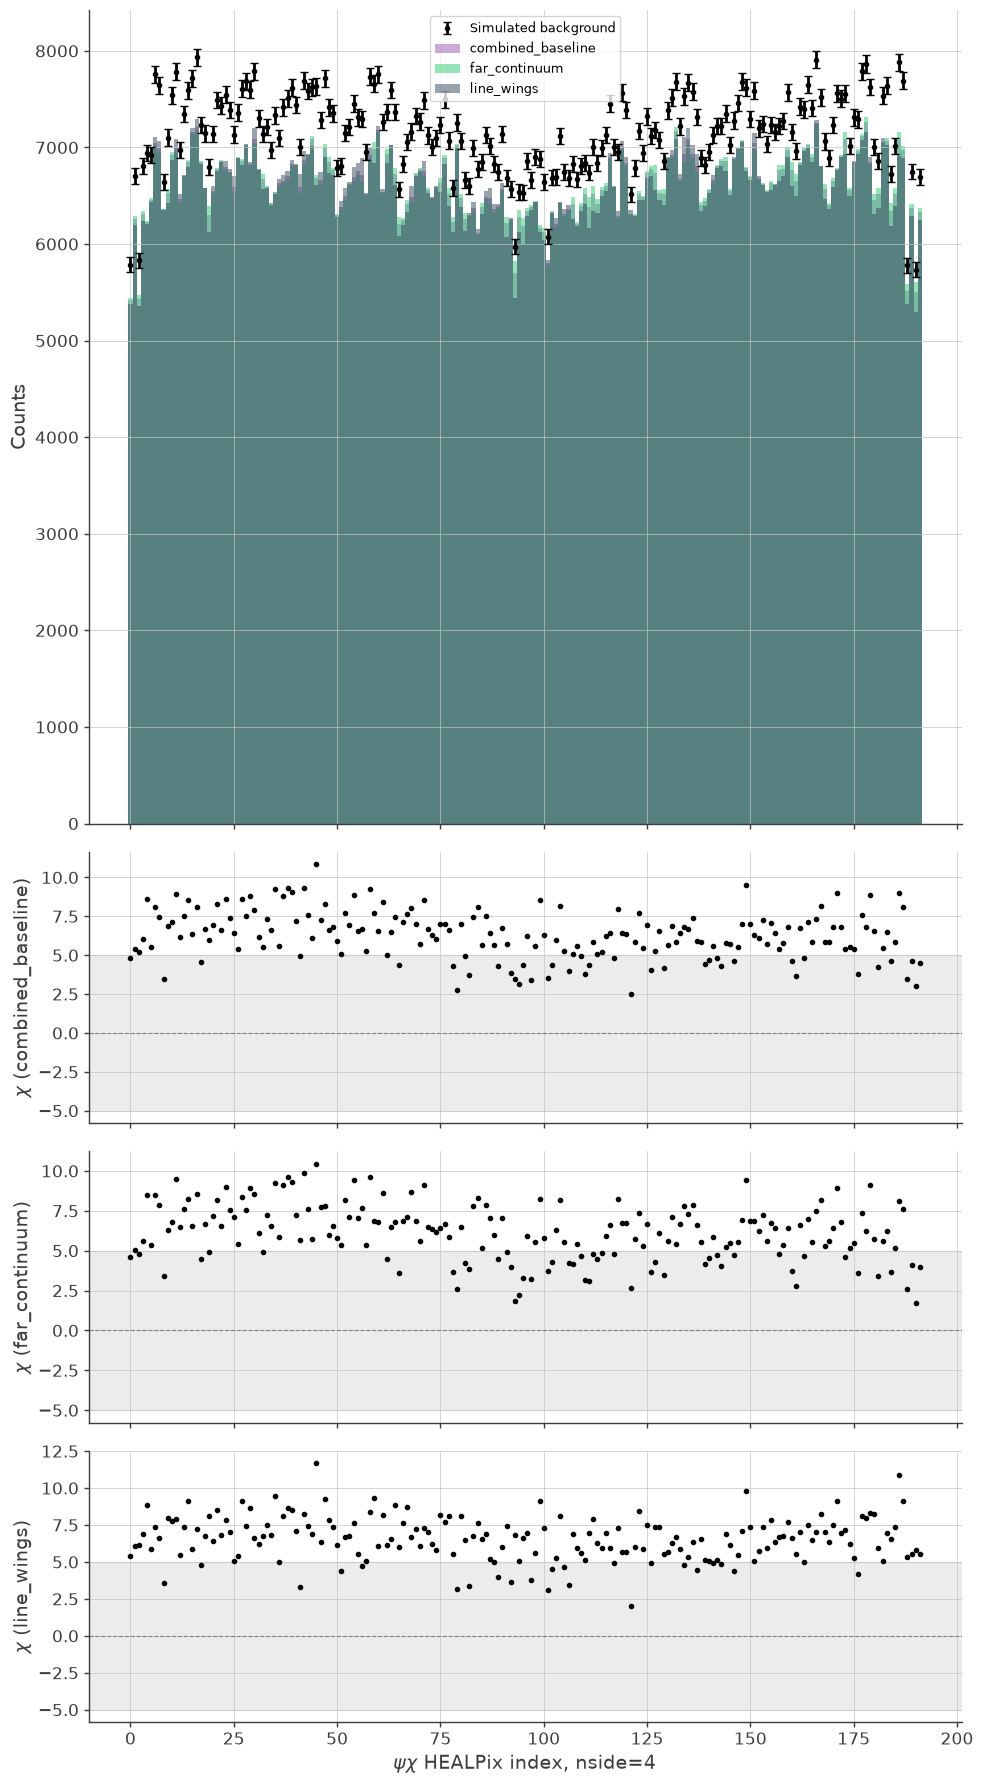

In [34]:
# Degrade the PsiChi distributions to nside=4 for comparison.
nside_out = 4

psichi_simulated = (
    simulated_background_511
    .project("PsiChi")
    .to_dense(copy=False)
)

psichi_simulated_rebinned = hp.ud_grade(
    psichi_simulated[:],
    nside_out,
    power=-2,
)

pixels = np.arange(
    hp.nside2npix(nside_out)
)

fig, axes = plt.subplots(
    len(diagnostic_background_models) + 1,
    1,
    figsize=(10, 18),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3]
        + [1] * len(diagnostic_background_models)
    },
)

# Compare the simulated background with all estimated models.
axes[0].errorbar(
    pixels,
    psichi_simulated_rebinned,
    yerr=np.sqrt(psichi_simulated_rebinned),
    fmt=".",
    color="black",
    label="Simulated background",
    capsize=3,
)

for name, model in diagnostic_background_models.items():
    psichi_model = (
        model
        .project("PsiChi")
        .to_dense(copy=False)
    )

    psichi_model_rebinned = hp.ud_grade(
        psichi_model[:],
        nside_out,
        power=-2,
    )

    axes[0].bar(
        pixels,
        psichi_model_rebinned,
        width=1,
        alpha=0.5,
        label=name,
    )

axes[0].set_ylabel("Counts")
axes[0].legend(fontsize=9)
axes[0].grid()

# Plot standardized residuals.
for ax, (name, model) in zip(
    axes[1:],
    diagnostic_background_models.items(),
):
    psichi_model = (
        model
        .project("PsiChi")
        .to_dense(copy=False)
    )

    psichi_model_rebinned = hp.ud_grade(
        psichi_model[:],
        nside_out,
        power=-2,
    )

    residual = (
        psichi_simulated_rebinned
        - psichi_model_rebinned
    ) / np.sqrt(psichi_simulated_rebinned)

    ax.plot(
        pixels,
        residual,
        ".",
        color="black",
    )
    ax.axhline(
        0,
        color="grey",
        linestyle="--",
        linewidth=0.8,
    )
    ax.axhspan(
        -5,
        5,
        color="grey",
        alpha=0.15,
    )
    ax.set_ylabel(fr"$\chi$ ({name})")
   
    ax.grid()

axes[-1].set_xlabel(
    rf"$\psi\chi$ HEALPix index, nside={nside_out}"
)

plt.tight_layout()
plt.show()

In [37]:
simulated_values = np.asarray(
    simulated_background_511
    .project("PsiChi")
    .to_dense(copy=False)
    .contents,
    dtype=float,
)

for name, model in diagnostic_background_models.items():
    model_values = np.asarray(
        model
        .project("PsiChi")
        .to_dense(copy=False)
        .contents,
        dtype=float,
    )

    normalization = simulated_values.sum() / model_values.sum()
    scaled_model_values = normalization * model_values

    residual = (
        simulated_values - scaled_model_values
    ) / np.sqrt(simulated_values)

    print(
        f"{name:20s} "
        f"scale = {normalization:.4f}, "
        f"mean chi = {residual.mean():+.3f}, "
        f"rms chi = {np.sqrt(np.mean(residual**2)):.3f}"
    )

combined_baseline    scale = 1.0806, mean chi = -0.030, rms chi = 1.132
far_continuum        scale = 1.0788, mean chi = -0.031, rms chi = 1.193
line_wings           scale = 1.0844, mean chi = -0.026, rms chi = 1.326


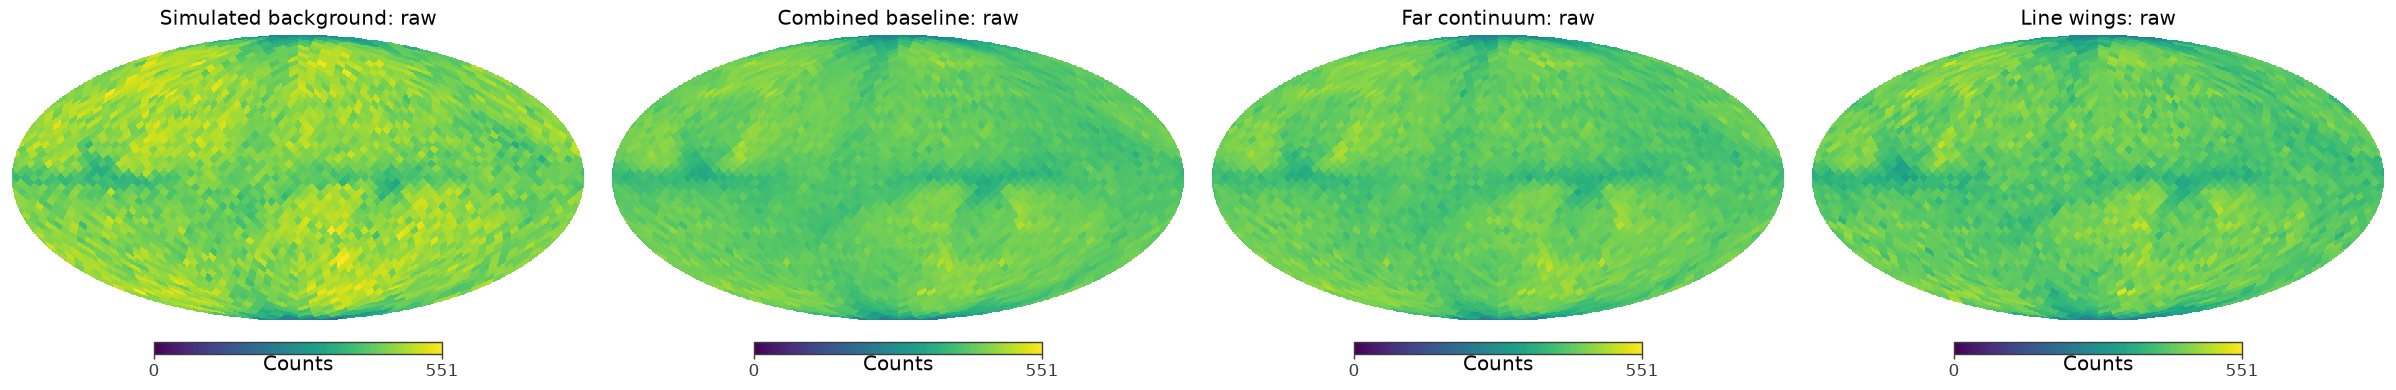

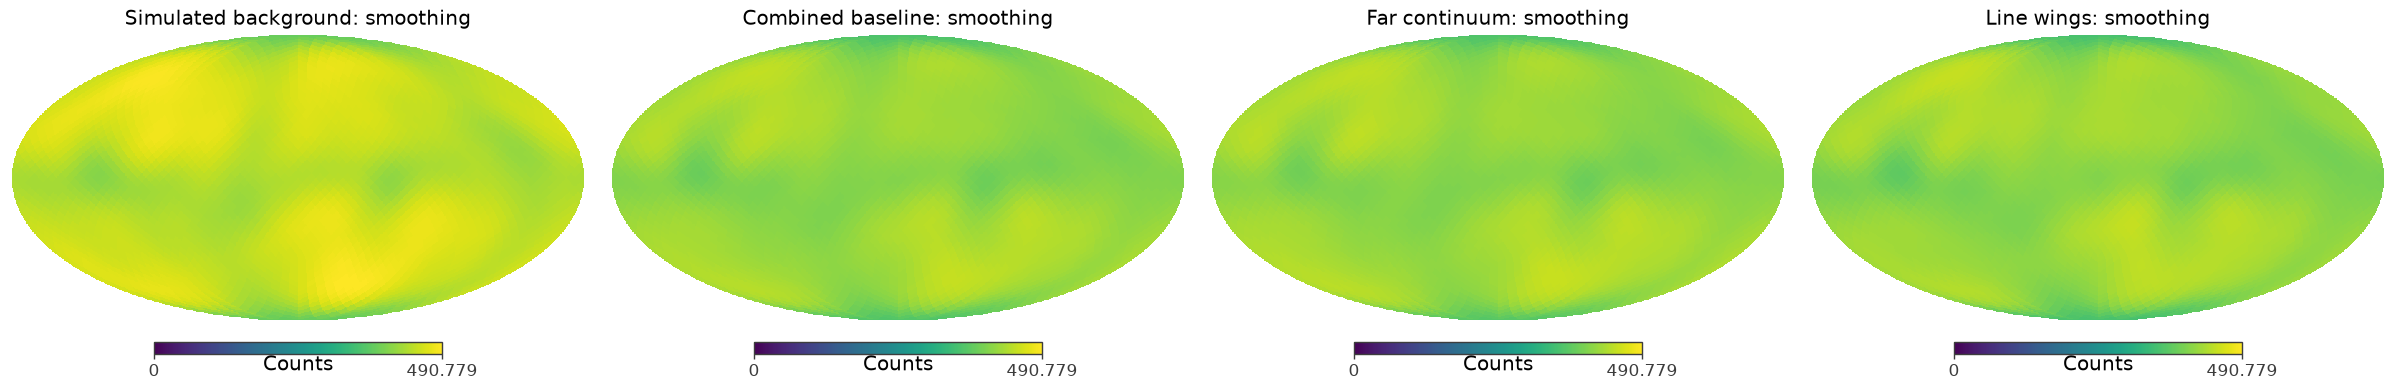

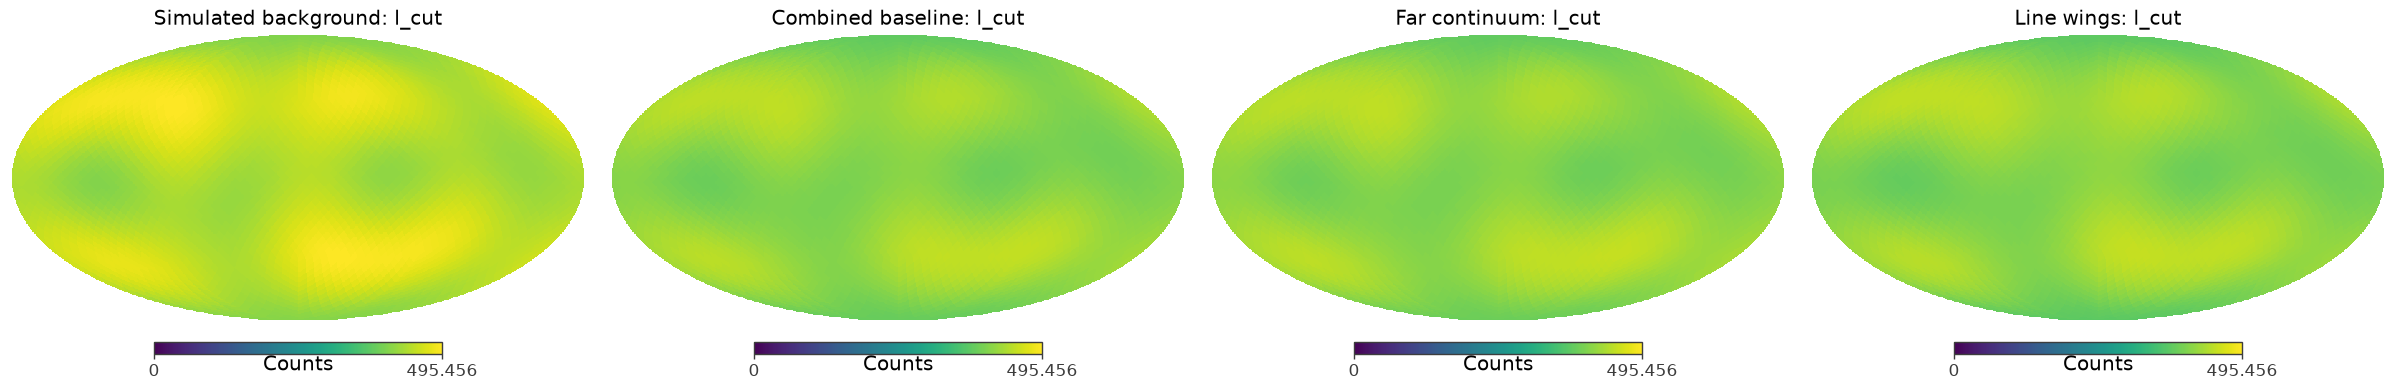

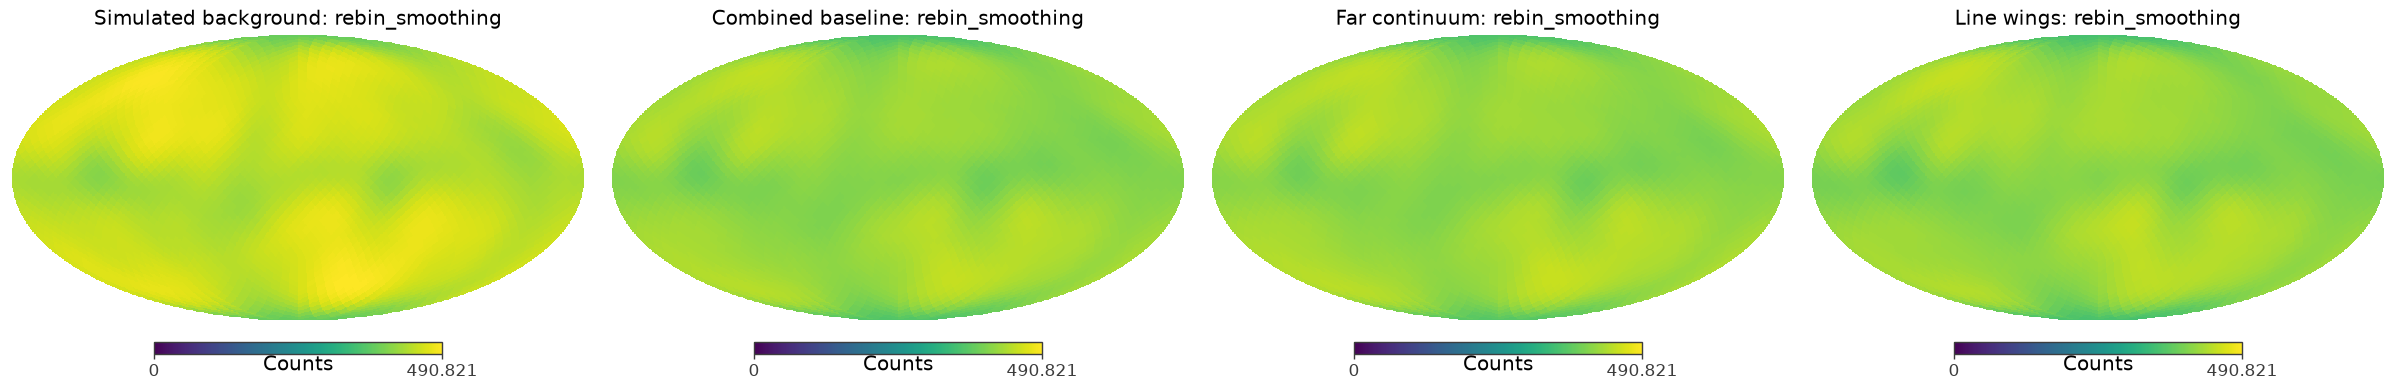

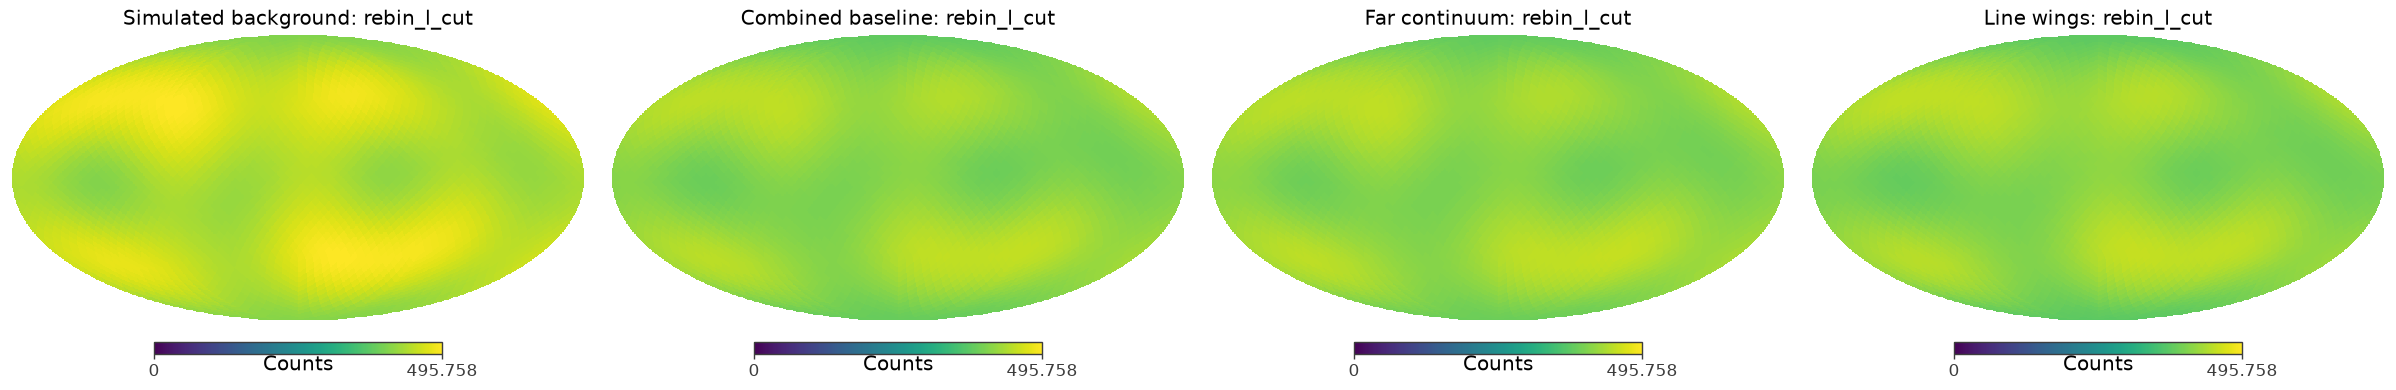

In [35]:
# Apply the same spatial-processing methods to the simulated background.
simulated_background_arrays = {}
simulated_background_raw = np.asarray(
    simulated_background_511.to_dense(copy=False).contents,
    dtype=float,
)

for method, settings in background_model_settings.items():
    simulated_values = simulated_background_raw.copy()
    smoothing_fwhm = settings.get("smoothing_fwhm")
    l_cut = settings.get("l_cut")
    rebin_phi = settings.get("rebin_phi")

    if smoothing_fwhm is not None or l_cut is not None:
        if rebin_phi is not None:
            rebinned, n_groups, phi_axis_idx = (
                line_background_estimator._rebin_phi(
                    simulated_values,
                    rebin_phi,
                )
            )
            rebinned = line_background_estimator._apply_spatial_filter(
                rebinned,
                simulated_background_511.axes,
                smoothing_fwhm,
                l_cut,
            )
            simulated_values = line_background_estimator._unbin_phi(
                simulated_values,
                rebinned,
                n_groups,
                rebin_phi,
                phi_axis_idx,
            )
        else:
            simulated_values = (
                line_background_estimator._apply_spatial_filter(
                    simulated_values,
                    simulated_background_511.axes,
                    smoothing_fwhm,
                    l_cut,
                )
            )

    simulated_background_arrays[method] = simulated_values

# Create one four-panel PsiChi comparison for each processing method.
for method in background_model_settings:
    psichi_maps = {
        "Simulated background": simulated_background_arrays[method].sum(
            axis=(0, 1)
        ),
        "Combined baseline": np.asarray(
            combined_models_511[method]
            .project("PsiChi")
            .to_dense(copy=False)
            .contents
        ),
        "Far continuum": np.asarray(
            continuum_models_511[method]
            .project("PsiChi")
            .to_dense(copy=False)
            .contents
        ),
        "Line wings": np.asarray(
            line_wing_models_511[method]
            .project("PsiChi")
            .to_dense(copy=False)
            .contents
        ),
    }

    common_max = max(values.max() for values in psichi_maps.values())
    fig = plt.figure(figsize=(24, 4))

    for panel, (name, values) in enumerate(psichi_maps.items(), start=1):
        hp.mollview(
            values,
            title=f"{name}: {method}",
            fig=fig.number,
            sub=(1, 4, panel),
            unit="Counts",
            min=0.0,
            max=common_max,
        )

    plt.show()

In [36]:
# # Build the fine-energy spectrum of the simulated background.
# with fits.open(
#     simulated_background_path,
#     memmap=True,
# ) as hdul:
#     simulated_background_energy_counts, _ = np.histogram(
#         hdul[1].data["Energies"],
#         bins=background_energy_bin_edges,
#     )

# # Obtain the measured spectrum containing sources plus background.
# observed_energy_spectrum = (
#     background_hist_all
#     .project("Em")
#     .to_dense(copy=False)
# )

# energy_centers = 0.5 * (
#     background_energy_bin_edges[:-1]
#     + background_energy_bin_edges[1:]
# )

# # Compare the measured spectrum with the simulated background.
# fig, ax = plt.subplots(figsize=(10, 5))

# ax.step(
#     energy_centers,
#     observed_energy_spectrum.contents,
#     where="mid",
#     label="Observed data",
#     color="purple",
# )

# ax.step(
#     energy_centers,
#     simulated_background_energy_counts,
#     where="mid",
#     label="Simulated background",
#     color="black",
# )

# ax.axvspan(
#     509,
#     513,
#     color="orange",
#     alpha=0.25,
#     label="511 keV source window",
# )

# ax.set_xlim(480, 540)
# ax.set_xlabel("Measured energy [keV]")
# ax.set_ylabel("Counts per 1 keV bin")
# ax.legend()
# ax.grid(alpha=0.3)

# plt.show()